# Gated Fusion CMLP SHAP Analysis
Code migrated from `gatedfusioncmlp_final_v3_experiment_edition_v2.py`.

In [1]:

import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from mrmr import mrmr_classif
HAS_MRMR = True
import umap
HAS_UMAP = True
import shap
HAS_SHAP = True
import mygene
HAS_MYGENE = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f">>> Running on: {DEVICE}")
SEED = 42
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
import cupy as cp
HAS_CUPY = True
print(">>> CuPy detected. GPU mRMR enabled.")
cp.random.seed(SEED)

BEST_PARAMS = {
    'latent_dim': 32,
    'hidden_dim': 128,
    'fusion_hidden_dim': 32,
    'dropout_encoder': 0.3,
    'dropout_rate': 0.4,
    'lr_fine': 0.000865,
    'weight_decay': 0.000435,
    'noise_level': 0.15,
    'focal_gamma': 3.5,
    'alpha_scale': 1.5
}

>>> Running on: cuda
>>> CuPy detected. GPU mRMR enabled.


In [2]:


class PerOmicCMAE(nn.Module):
    """Encoder for Supervised Learning"""
    def __init__(self, input_dim, latent_dim=64, hidden_dim=256, dropout_encoder=0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_encoder),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x, noise_level=0.0, noise_type='gaussian'):
        # Noise Injection during training
        if self.training and noise_level > 0:
            if noise_type == 'gaussian':
                noise = torch.randn_like(x) * noise_level
                x_corrupted = x + noise
            elif noise_type == 'uniform':
                noise = (torch.rand_like(x) - 0.5) * 2 * noise_level
                x_corrupted = x + noise
            elif noise_type == 'dropout':
                mask = torch.bernoulli(torch.ones_like(x) * (1 - noise_level))
                x_corrupted = x * mask
            else:
                x_corrupted = x
        else:
            x_corrupted = x

        z = self.encoder(x_corrupted)
        return z

class GatedAttentionFusion(nn.Module):
    """Gated Attention Fusion"""
    def __init__(self, latent_dim=64, num_classes=4, dropout_rate=0.3, hidden_dim=64):
        super().__init__()
        self.gate_rna = nn.Linear(latent_dim, 1)
        self.gate_meth = nn.Linear(latent_dim, 1)
        self.gate_clin = nn.Linear(latent_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )
        self.drop_rate = dropout_rate

    def forward(self, z_rna, z_meth, z_clin, apply_dropout=False):
        if apply_dropout and self.training:
            if torch.rand(1).item() < self.drop_rate: z_rna = torch.zeros_like(z_rna)
            if torch.rand(1).item() < self.drop_rate: z_meth = torch.zeros_like(z_meth)
            if torch.rand(1).item() < self.drop_rate: z_clin = torch.zeros_like(z_clin)

        w_rna = torch.sigmoid(self.gate_rna(z_rna))
        w_meth = torch.sigmoid(self.gate_meth(z_meth))
        w_clin = torch.sigmoid(self.gate_clin(z_clin))

        # Store for analysis
        self.last_weights = {'RNA': w_rna, 'Meth': w_meth, 'CNV': w_clin}

        z_fused = torch.cat([w_rna * z_rna, w_meth * z_meth, w_clin * z_clin], dim=1)

        return self.classifier(z_fused), z_fused

class SimpleConcatFusion(nn.Module):
    """Baseline Fusion without Gating (Simple Concatenation)"""
    def __init__(self, latent_dim=64, num_classes=4, dropout_rate=0.3, hidden_dim=64):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, z_rna, z_meth, z_clin, apply_dropout=False):
        # Simply concatenate without weighting
        z_fused = torch.cat([z_rna, z_meth, z_clin], dim=1)
        return self.classifier(z_fused), z_fused

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss

        if self.alpha is not None:
            if isinstance(self.alpha, (float, int)):
                alpha_t = self.alpha
            else:
                if self.alpha.device != inputs.device:
                    self.alpha = self.alpha.to(inputs.device)
                alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def load_raw_aligned_data():
    print(f"\n>>> LOADING RAW ALIGNED DATA")
    pheno_path = "Data/phenotype_clean.csv"
    if not os.path.exists(pheno_path):
        raise FileNotFoundError(f"{pheno_path} not found.")

    pheno = pd.read_csv(pheno_path, index_col=0)
    SUBTYPES_OF_INTEREST = [
        'Leiomyosarcoma, NOS', 'Dedifferentiated liposarcoma',
        'Undifferentiated sarcoma', 'Fibromyxosarcoma'
    ]
    col_name = 'primary_diagnosis.diagnoses'
    mask = pheno[col_name].isin(SUBTYPES_OF_INTEREST)
    pheno = pheno[mask]

    def load_omic(path, name):
        if not os.path.exists(path): return None
        df = pd.read_csv(path, index_col=0)
        df = df.T  # samples x features
        return df

    rna = load_omic("Data/expression_log.csv", "RNA")
    meth = load_omic("Data/methylation_mvalues.csv", "Methylation")
    cnv = load_omic("Data/cnv_log.csv", "CNV")

    common_samples = pheno.index.intersection(rna.index).intersection(meth.index).intersection(cnv.index)
    print(f"  Common Samples: {len(common_samples)}")

    pheno = pheno.loc[common_samples]
    rna = rna.loc[common_samples]
    meth = meth.loc[common_samples]
    cnv = cnv.loc[common_samples]

    le = LabelEncoder()
    Y = le.fit_transform(pheno[col_name])

    class_counts = np.bincount(Y)
    class_weights = len(Y) / (len(class_counts) * class_counts)
    class_weights = class_weights / class_weights.sum()

    return rna, meth, cnv, Y, le.classes_, class_weights

# --- Advanced Feature Preparation Helpers ---
import time

def f_classif_gpu(X, y):
    """Compute ANOVA F-value on GPU."""
    n_samples, n_features = X.shape
    classes = cp.unique(y)
    n_classes = len(classes)

    mean_total = cp.mean(X, axis=0)
    var_total = cp.var(X, axis=0)
    ss_total = var_total * n_samples

    ss_between = cp.zeros(n_features, dtype=cp.float32)

    for c in classes:
        mask = (y == c)
        n_c = cp.sum(mask)
        mean_c = cp.mean(X[mask], axis=0)
        ss_between += n_c * (mean_c - mean_total)**2

    ss_within = ss_total - ss_between

    df_between = n_classes - 1
    df_within = n_samples - n_classes

    ms_between = ss_between / df_between
    ms_within = ss_within / df_within

    f_stat = cp.divide(ms_between, ms_within)
    f_stat = cp.nan_to_num(f_stat, nan=0.0)
    return f_stat

def correlation_gpu(X, y):
    """Compute Pearson correlation on GPU."""
    X_centered = X - X.mean(axis=0)
    y_centered = y - y.mean()

    numerator = cp.dot(y_centered, X_centered)
    X_ss = cp.sum(X_centered**2, axis=0)
    y_ss = cp.sum(y_centered**2)

    denominator = cp.sqrt(X_ss * y_ss)
    corr = numerator / denominator
    return cp.abs(corr)

def mrmr_gpu_impl(X, y, K):
    """GPU accelerated mRMR."""
    # Move to GPU if not already
    X_gpu = cp.asarray(X, dtype=cp.float32)
    y_gpu = cp.asarray(y, dtype=cp.int32)

    n_samples, n_features = X_gpu.shape

    # 1. Relevance
    relevance = f_classif_gpu(X_gpu, y_gpu)

    selected_indices = []
    candidate_mask = cp.ones(n_features, dtype=bool)
    redundancy = cp.zeros(n_features, dtype=cp.float32)

    for k in range(K):
        if k == 0:
            scores = relevance
        else:
            scores = relevance - (redundancy / k)

        current_scores = scores.copy()
        current_scores[~candidate_mask] = -np.inf

        best_idx = int(cp.argmax(current_scores))
        selected_indices.append(best_idx)
        candidate_mask[best_idx] = False

        if k < K - 1:
            last_selected_feature = X_gpu[:, best_idx]
            new_corrs = correlation_gpu(X_gpu, last_selected_feature)
            redundancy += new_corrs

    return selected_indices

def variance_filter(train_vals, val_vals, top_k):
    """Filter features by variance, calculated on train data only."""
    if train_vals.shape[1] <= top_k:
        return train_vals, val_vals, np.arange(train_vals.shape[1])

    vars = np.nanvar(train_vals, axis=0)
    top_idx = np.argpartition(vars, -top_k)[-top_k:]
    top_idx = np.sort(top_idx)

    return train_vals[:, top_idx], val_vals[:, top_idx], top_idx

def mrmr_filter(train_vals, val_vals, train_y, top_k, feat_names):
    """Apply mRMR feature selection on Training data, apply to Validation."""
    if train_vals.shape[1] <= top_k:
        return train_vals, val_vals, np.arange(train_vals.shape[1])

    # GPU ACCELERATION
    if HAS_CUPY:
        try:
            selected_indices = mrmr_gpu_impl(train_vals, train_y, top_k)
            if hasattr(selected_indices, 'get'): selected_indices = selected_indices.get()
            selected_indices = list(selected_indices)

            return train_vals[:, selected_indices], val_vals[:, selected_indices], selected_indices
        except Exception as e:
            print(f"   [GPU] mRMR Failed: {e}. Falling back to CPU.")
            # Fallthrough to CPU

    if not HAS_MRMR:
        return variance_filter(train_vals, val_vals, top_k) # Fallback

    # mRMR requires DataFrame with columns
    df_train = pd.DataFrame(train_vals, columns=[f"f_{i}" for i in range(train_vals.shape[1])])
    y_series = pd.Series(train_y)

    # Select features
    selected_feats = mrmr_classif(X=df_train, y=y_series, K=top_k, show_progress=False)

    # Map back to indices
    selected_indices = [int(f.split('_')[1]) for f in selected_feats]

    return train_vals[:, selected_indices], val_vals[:, selected_indices], selected_indices

def prepare_fold_data_advanced(t_idx, v_idx, df_rna, df_meth, df_cnv, Y):
    """Pipeline: Variance (Top 5k) -> KNN Impute -> mRMR (Top 600) -> Scale"""

    # 1. Split
    tr_r, val_r = df_rna.iloc[t_idx].values, df_rna.iloc[v_idx].values
    tr_m, val_m = df_meth.iloc[t_idx].values, df_meth.iloc[v_idx].values
    tr_c, val_c = df_cnv.iloc[t_idx].values, df_cnv.iloc[v_idx].values
    y_tr = Y[t_idx]

    # 2. Variance Filter (Speed up KNN)
    tr_r, val_r, _ = variance_filter(tr_r, val_r, top_k=6000)
    tr_m, val_m, _ = variance_filter(tr_m, val_m, top_k=10000)
    tr_c, val_c, _ = variance_filter(tr_c, val_c, top_k=8000)

    # 3. KNN Imputation
    imp = KNNImputer(n_neighbors=12)
    tr_r = imp.fit_transform(tr_r); val_r = imp.transform(val_r)
    tr_m = imp.fit_transform(tr_m); val_m = imp.transform(val_m)
    tr_c = imp.fit_transform(tr_c); val_c = imp.transform(val_c)

    # 4. mRMR Feature Selection (Refine for Relevance)
    tr_r, val_r, _ = mrmr_filter(tr_r, val_r, y_tr, top_k=500, feat_names=None)
    tr_m, val_m, _ = mrmr_filter(tr_m, val_m, y_tr, top_k=400, feat_names=None)
    tr_c, val_c, _ = mrmr_filter(tr_c, val_c, y_tr, top_k=300, feat_names=None)

    # 5. Standard Scaling
    sc = StandardScaler()
    tr_r = sc.fit_transform(tr_r); val_r = sc.transform(val_r)
    tr_m = sc.fit_transform(tr_m); val_m = sc.transform(val_m)
    tr_c = sc.fit_transform(tr_c); val_c = sc.transform(val_c)

    return (
        torch.FloatTensor(tr_r).to(DEVICE), torch.FloatTensor(val_r).to(DEVICE), tr_r.shape[1],
        torch.FloatTensor(tr_m).to(DEVICE), torch.FloatTensor(val_m).to(DEVICE), tr_m.shape[1],
        torch.FloatTensor(tr_c).to(DEVICE), torch.FloatTensor(val_c).to(DEVICE), tr_c.shape[1],
        torch.LongTensor(y_tr).to(DEVICE), torch.LongTensor(Y[v_idx]).to(DEVICE)
    )

def train_fold_single_model(tr_data, val_data, dims, params, class_weights, use_gating=True, class_names_len=4):
    """(Helper) Trains a single model (Gated or Baseline) for one fold."""
    (tr_r, tr_m, tr_c, y_tr) = tr_data
    (val_r, val_m, val_c, y_val) = val_data
    (dim_r, dim_m, dim_c) = dims

    # Init Encoders
    enc_r = PerOmicCMAE(dim_r, params['latent_dim'], params['hidden_dim'], params['dropout_encoder']).to(DEVICE)
    enc_m = PerOmicCMAE(dim_m, params['latent_dim'], params['hidden_dim'], params['dropout_encoder']).to(DEVICE)
    enc_c = PerOmicCMAE(dim_c, params['latent_dim'], params['hidden_dim'], params['dropout_encoder']).to(DEVICE)

    # Init Fusion
    if use_gating:
        fusion = GatedAttentionFusion(params['latent_dim'], class_names_len, params['dropout_rate'], params['fusion_hidden_dim']).to(DEVICE)
    else:
        fusion = SimpleConcatFusion(params['latent_dim'], class_names_len, params['dropout_rate'], params['fusion_hidden_dim']).to(DEVICE)

    optimizer = optim.AdamW(
        list(enc_r.parameters()) + list(enc_m.parameters()) +
        list(enc_c.parameters()) + list(fusion.parameters()),
        lr=params['lr_fine'], weight_decay=params['weight_decay']
    )

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    alpha = torch.FloatTensor(class_weights * params['alpha_scale']).to(DEVICE)
    criterion = FocalLoss(gamma=params['focal_gamma'], alpha=alpha)

    best_loss = float('inf')
    patience = 20
    cur_pat = 0
    best_res = None

    for epoch in range(300):
        enc_r.train(); enc_m.train(); enc_c.train(); fusion.train()

        z_r = enc_r(tr_r, noise_level=params['noise_level'])
        z_m = enc_m(tr_m, noise_level=params['noise_level'])
        z_c = enc_c(tr_c, noise_level=params['noise_level'])

        logits, _ = fusion(z_r, z_m, z_c, apply_dropout=True)
        loss = criterion(logits, y_tr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        enc_r.eval(); enc_m.eval(); enc_c.eval(); fusion.eval()
        with torch.no_grad():
            v_z_r = enc_r(val_r)
            v_z_m = enc_m(val_m)
            v_z_c = enc_c(val_c)
            v_logits, v_latent = fusion(v_z_r, v_z_m, v_z_c)
            val_loss = criterion(v_logits, y_val).item()

        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            cur_pat = 0
            # Save Predictions
            v_preds = v_logits.argmax(dim=1).cpu().numpy()
            v_targets = y_val.cpu().numpy()
            v_embeddings = v_latent.cpu().numpy() 

            # Save weights if gated
            current_weights = None
            if use_gating:
                 current_weights = {
                     'RNA': fusion.last_weights['RNA'].detach().cpu().numpy().flatten(),
                     'Meth': fusion.last_weights['Meth'].detach().cpu().numpy().flatten(),
                     'CNV': fusion.last_weights['CNV'].detach().cpu().numpy().flatten()
                 }

            best_res = (v_preds, v_targets, v_embeddings, current_weights)
        else:
            cur_pat += 1

        if cur_pat >= patience:
            break

    return best_res




>>> LOADING RAW ALIGNED DATA
  Common Samples: 205

STARTING EVALUATION (Gated Only)

>>> Fold 1 / 5
   [1] Training Gated Fusion Model...
   Fold 1 Result:
     Gated    -> F1: 0.8118, Acc: 0.9024

>>> Fold 2 / 5
   [1] Training Gated Fusion Model...
   Fold 2 Result:
     Gated    -> F1: 0.9030, Acc: 0.9268

>>> Fold 3 / 5
   [1] Training Gated Fusion Model...
   Fold 3 Result:
     Gated    -> F1: 0.7313, Acc: 0.7805

>>> Fold 4 / 5
   [1] Training Gated Fusion Model...
   Fold 4 Result:
     Gated    -> F1: 0.6555, Acc: 0.7561

>>> Fold 5 / 5
   [1] Training Gated Fusion Model...
   Fold 5 Result:
     Gated    -> F1: 0.7570, Acc: 0.8049

FINAL CLASSIFICATION METRICS

[GATED FUSION]
F1 Macro:  0.7717 (+/- 0.0827)
Accuracy:  0.8341 (+/- 0.0679)
Precision: 0.7773
Recall:    0.7879

CLUSTERING METRICS (Latent Space)
Silhouette Score (True Labels): 0.0342
Silhouette Score (K-Means):   0.1334
Adjusted Rand Index (ARI):    -0.0208
Normalized Mutual Info (NMI): 0.1494
Running t-SNE...
Ru

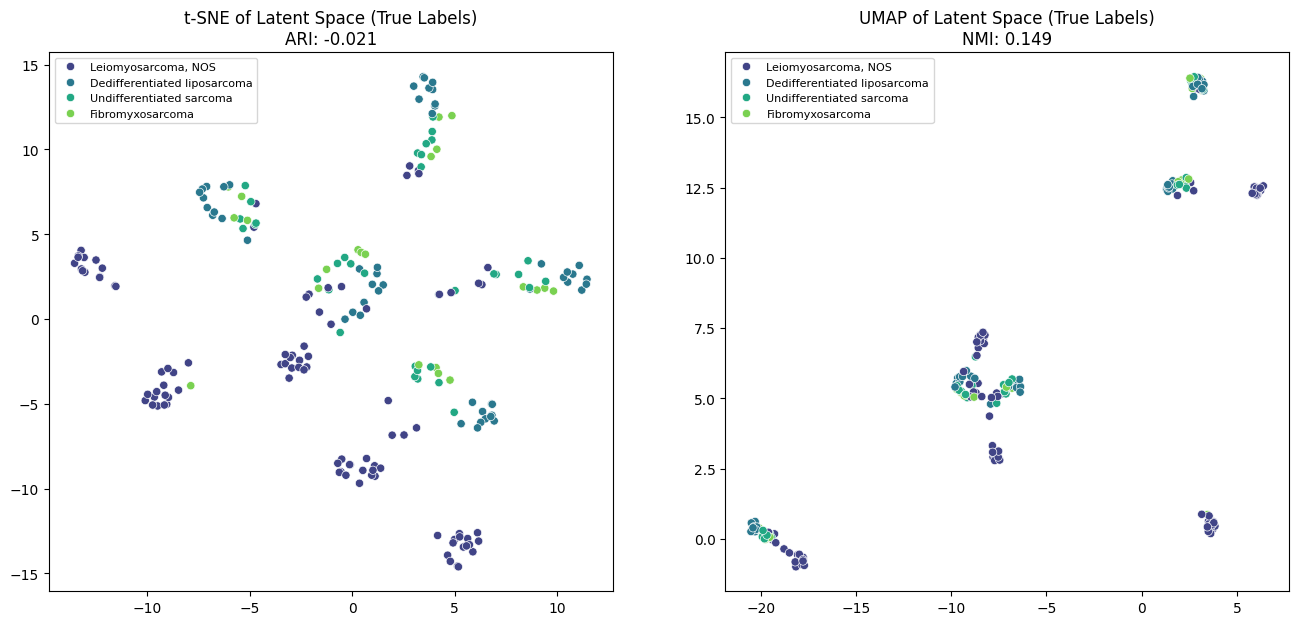

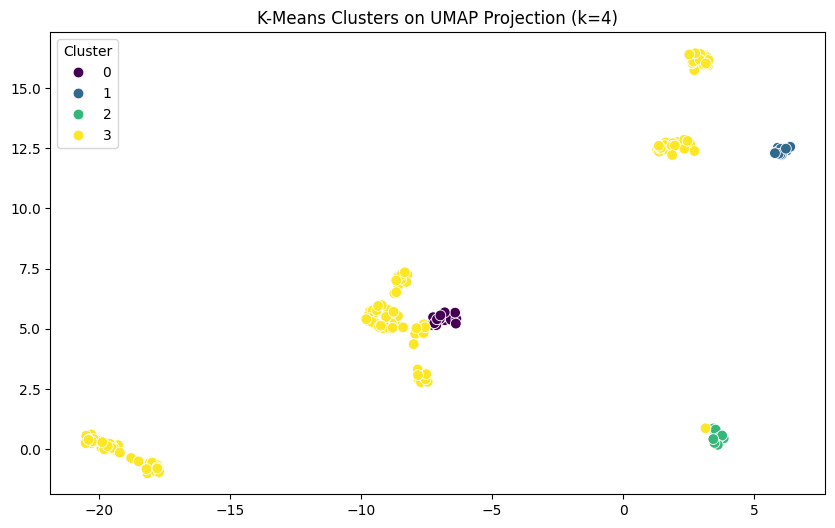

In [3]:
def run_final_evaluation(rna_df, meth_df, cnv_df, Y, class_names, class_weights, params):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Storage for GATED model (Primary)
    all_preds = np.zeros(len(Y))
    all_targets = np.zeros(len(Y))
    all_latent = np.zeros((len(Y), params['latent_dim']*3))
    all_weights = {'RNA': np.zeros(len(Y)), 'Meth': np.zeros(len(Y)), 'CNV': np.zeros(len(Y))}

    metrics_gated = {'f1_macro': [], 'accuracy': [], 'precision': [], 'recall': []}

    print(f"\n{'='*60}")
    print(f"STARTING EVALUATION (Gated Only)")
    print(f"{'='*60}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(rna_df, Y)):
        print(f"\n>>> Fold {fold+1} / 5")

        # 1. Prepare Data
        (tr_r, val_r, dim_r,
         tr_m, val_m, dim_m,
         tr_c, val_c, dim_c,
         y_tr, y_val) = prepare_fold_data_advanced(train_idx, val_idx, rna_df, meth_df, cnv_df, Y)

        tr_data = (tr_r, tr_m, tr_c, y_tr)
        val_data = (val_r, val_m, val_c, y_val)
        dims = (dim_r, dim_m, dim_c)

        # 2. Train Gated Model
        print("   [1] Training Gated Fusion Model...")
        g_preds, g_targ, g_lat, g_w = train_fold_single_model(
            tr_data, val_data, dims, params, class_weights, use_gating=True, class_names_len=len(class_names)
        )

        # Store Gated Results
        all_preds[val_idx] = g_preds
        all_targets[val_idx] = g_targ
        all_latent[val_idx] = g_lat 
        if g_w:
            all_weights['RNA'][val_idx] = g_w['RNA']
            all_weights['Meth'][val_idx] = g_w['Meth']
            all_weights['CNV'][val_idx] = g_w['CNV']

        metrics_gated['f1_macro'].append(f1_score(g_targ, g_preds, average='macro'))
        metrics_gated['accuracy'].append(accuracy_score(g_targ, g_preds))
        metrics_gated['precision'].append(precision_score(g_targ, g_preds, average='macro'))
        metrics_gated['recall'].append(recall_score(g_targ, g_preds, average='macro'))


        print(f"   Fold {fold+1} Result:")
        print(f"     Gated    -> F1: {metrics_gated['f1_macro'][-1]:.4f}, Acc: {metrics_gated['accuracy'][-1]:.4f}")

    return metrics_gated, None, all_preds, all_targets, all_latent, all_weights

# Load Data
try:
    rna_df, meth_df, cnv_df, Y, class_names, class_weights = load_raw_aligned_data()

    # Run Eval
    # Run Eval
    metrics_gated, _, all_preds, all_targets, all_latent, all_weights = run_final_evaluation(
        rna_df, meth_df, cnv_df, Y, class_names, class_weights, BEST_PARAMS
    )

    # helper: print stats
    def print_stats(name, m):
        print(f"\n[{name}]")
        print(f"F1 Macro:  {np.mean(m['f1_macro']):.4f} (+/- {np.std(m['f1_macro']):.4f})")
        print(f"Accuracy:  {np.mean(m['accuracy']):.4f} (+/- {np.std(m['accuracy']):.4f})")
        print(f"Precision: {np.mean(m['precision']):.4f}")
        print(f"Recall:    {np.mean(m['recall']):.4f}")

    # --- Reporting ---
    print(f"\n{'='*30}")
    print("FINAL CLASSIFICATION METRICS")
    print(f"{'='*30}")

    print_stats("GATED FUSION", metrics_gated)
    print(f"\n{'='*30}")
    print("CLUSTERING METRICS (Latent Space)")
    print(f"{'='*30}")

    # 1. True Labels Silhouette
    sil_true = silhouette_score(all_latent, all_targets)
    print(f"Silhouette Score (True Labels): {sil_true:.4f}")

    # 2. K-Means Clustering
    kmeans = KMeans(n_clusters=len(class_names), random_state=SEED)
    kmeans_preds = kmeans.fit_predict(all_latent)

    sil_km = silhouette_score(all_latent, kmeans_preds)
    ari = adjusted_rand_score(all_targets, kmeans_preds)
    nmi = normalized_mutual_info_score(all_targets, kmeans_preds)

    print(f"Silhouette Score (K-Means):   {sil_km:.4f}")
    print(f"Adjusted Rand Index (ARI):    {ari:.4f}")
    print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()

# TSNE
# --- Visualizations ---
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_tsne = tsne.fit_transform(all_latent)
sns.scatterplot(
    x=z_tsne[:,0], y=z_tsne[:,1],
    hue=[class_names[int(i)] for i in all_targets],
    palette='viridis', ax=axes[0]
)
axes[0].set_title(f't-SNE of Latent Space (True Labels)\nARI: {ari:.3f}')
axes[0].legend(prop={'size': 8})
# UMAP (if available)
if HAS_UMAP:
    print("Running UMAP...")
    reducer = umap.UMAP(random_state=SEED)
    z_umap = reducer.fit_transform(all_latent)

    sns.scatterplot(
        x=z_umap[:,0], y=z_umap[:,1],
        hue=[class_names[int(i)] for i in all_targets],
        palette='viridis', ax=axes[1]
    )
    axes[1].set_title(f'UMAP of Latent Space (True Labels)\nNMI: {nmi:.3f}')
    axes[1].legend(prop={'size': 8})
else:
    axes[1].text(0.5, 0.5, 'UMAP Not Installed', ha='center')
    plt.tight_layout()
# plt.savefig('cluster_analysis.png', dpi=300)
    plt.show()

# --- K-Means Clustering Analysis ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Ensure latent data is available
if 'all_latent' in locals():
    print(f">>> Running Independent K-Means Clustering...")
    n_clusters = len(class_names) if 'class_names' in locals() else 4
    rand_seed = SEED if 'SEED' in locals() else 42

    print(f"    Number of Clusters (k): {n_clusters}")

    # 1. Fit K-Means
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=rand_seed)
    cluster_labels = kmeans_model.fit_predict(all_latent)

    # 2. Metrics
    sil_score = silhouette_score(all_latent, cluster_labels)
    print(f"    Silhouette Score: {sil_score:.4f}")

    if 'all_targets' in locals():
        ari_score = adjusted_rand_score(all_targets, cluster_labels)
        nmi_score = normalized_mutual_info_score(all_targets, cluster_labels)
        print(f"    Adjusted Rand Index (ARI):    {ari_score:.4f}")
        print(f"    Normalized Mutual Info (NMI): {nmi_score:.4f}")

    if 'z_umap' in locals():
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=z_umap[:, 0], y=z_umap[:, 1], hue=cluster_labels, palette='viridis', s=60, legend='full')
        plt.title(f'K-Means Clusters on UMAP Projection (k={n_clusters})')
        plt.legend(title='Cluster')
        plt.show()
    elif 'z_tsne' in locals():
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=z_tsne[:, 0], y=z_tsne[:, 1], hue=cluster_labels, palette='viridis', s=60, legend='full')
        plt.title(f'K-Means Clusters on t-SNE Projection (k={n_clusters})')
        plt.legend(title='Cluster')
        plt.show()
    else:
        print("Note: 'z_umap' or 'z_tsne' not found. Skipping visualization.")


OMICS IMPACT ANALYSIS (%)
RNA Impact: 34.38% (+/- 3.47%)
Meth Impact: 34.82% (+/- 3.24%)
CNV Impact: 30.80% (+/- 3.80%)


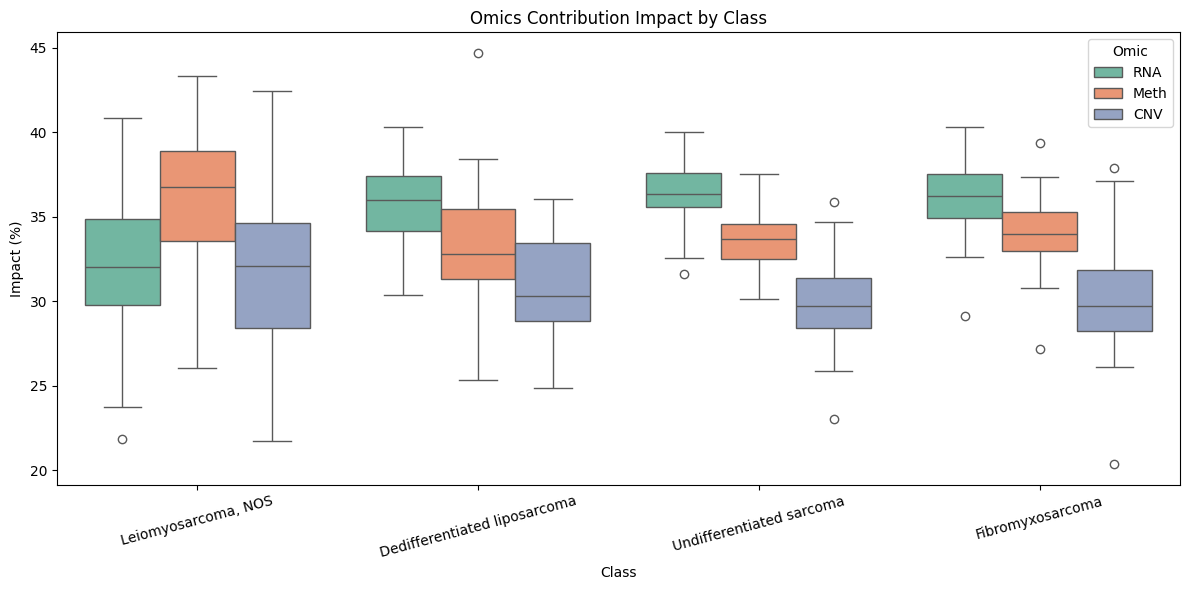

In [4]:
# --- Omics Impact Analysis ---
if 'all_weights' in locals() and 'all_targets' in locals():
    print(f"\n{'='*30}")
    print("OMICS IMPACT ANALYSIS (%)")
    print(f"{'='*30}")
    w_stack = np.stack([all_weights['RNA'], all_weights['Meth'], all_weights['CNV']], axis=1)
    omics_names = ['RNA', 'Meth', 'CNV']
    w_sum = w_stack.sum(axis=1, keepdims=True)
    w_sum[w_sum == 0] = 1e-8
    w_pct = (w_stack / w_sum) * 100

    # Global Mean
    mean_impact = w_pct.mean(axis=0)
    std_impact = w_pct.std(axis=0)

    for i, name in enumerate(omics_names):
        print(f"{name} Impact: {mean_impact[i]:.2f}% (+/- {std_impact[i]:.2f}%)")

    # By Class Analysis
    df_impact = pd.DataFrame(w_pct, columns=omics_names)
    df_impact['Class'] = [class_names[int(t)] for t in all_targets]
    df_melt = df_impact.melt(id_vars='Class', var_name='Omic', value_name='Impact (%)')

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_melt, x='Class', y='Impact (%)', hue='Omic', palette='Set2')
    plt.title('Omics Contribution Impact by Class')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


SHAP FEATURE IMPORTANCE ANALYSIS (Top 15 Genes per Omic)
Training a final model on full data for SHAP analysis...
>>> Training a final model on full data for SHAP analysis (With Name Tracking)...
   [SHAP Prep] Initial Shapes: RNA (205, 60660), Meth (205, 419546), CNV (205, 56751)
   [SHAP Prep] Variance Filter...
   [SHAP Prep] Imputing...
   [SHAP Prep] mRMR...
   [SHAP Prep] Final Shapes: RNA (205, 500), Meth (205, 400), CNV (205, 300)
   Training for SHAP (100 epochs)...
   Training complete.
   Generating SHAP summary for RNA...


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


      [SHAP raw] shape=(100, 500, 4), X_np=(100, 500)
      [SHAP] sv_plot (100, 500), X_np (100, 500), mean_shap (500,)
      Mapping RNA Ensembl IDs to gene symbols...


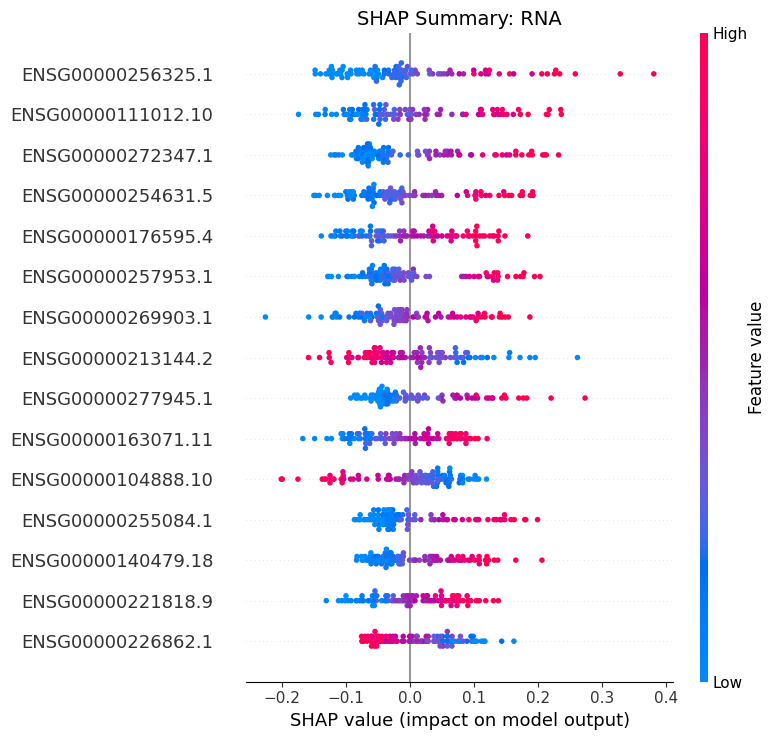


[RNA TOP 15]
   1. ENSG00000272347.1         (SHAP: 0.0359)
   2. ENSG00000111012.10        (SHAP: 0.0321)
   3. ENSG00000256325.1         (SHAP: 0.0318)
   4. ENSG00000166035.11        (SHAP: 0.0316)
   5. ENSG00000108823.16        (SHAP: 0.0298)
   6. ENSG00000163017.14        (SHAP: 0.0290)
   7. ENSG00000163739.5         (SHAP: 0.0283)
   8. ENSG00000283273.1         (SHAP: 0.0282)
   9. ENSG00000232725.1         (SHAP: 0.0282)
  10. ENSG00000140479.18        (SHAP: 0.0280)
  11. ENSG00000179528.16        (SHAP: 0.0277)
  12. ENSG00000112183.15        (SHAP: 0.0275)
  13. ENSG00000232527.8         (SHAP: 0.0273)
  14. ENSG00000104888.10        (SHAP: 0.0272)
  15. ENSG00000254631.5         (SHAP: 0.0272)
   Generating SHAP summary for Meth...
      [SHAP raw] shape=(100, 400, 4), X_np=(100, 400)
      [SHAP] sv_plot (100, 400), X_np (100, 400), mean_shap (400,)


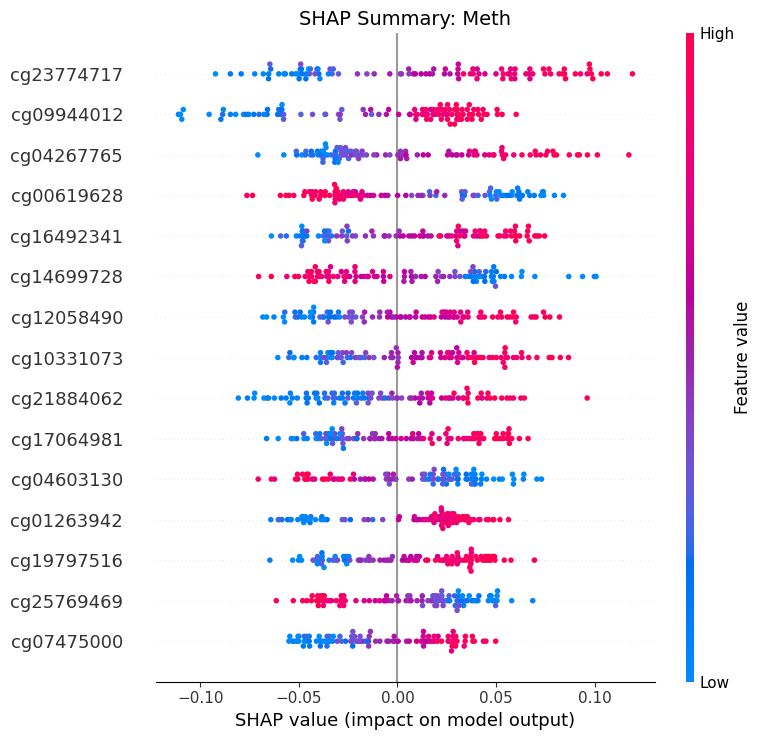


[Meth TOP 15]
   1. cg00619628                (SHAP: 0.0368)
   2. cg10402321                (SHAP: 0.0336)
   3. cg07946277                (SHAP: 0.0319)
   4. cg03855388                (SHAP: 0.0308)
   5. cg04839131                (SHAP: 0.0303)
   6. cg14699728                (SHAP: 0.0285)
   7. cg05825244                (SHAP: 0.0283)
   8. cg16492341                (SHAP: 0.0282)
   9. cg23167035                (SHAP: 0.0281)
  10. cg23774717                (SHAP: 0.0274)
  11. cg14412134                (SHAP: 0.0270)
  12. cg05317714                (SHAP: 0.0266)
  13. cg26317006                (SHAP: 0.0263)
  14. cg18262591                (SHAP: 0.0260)
  15. cg15380291                (SHAP: 0.0257)
   Generating SHAP summary for CNV...


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


      [SHAP raw] shape=(100, 300, 4), X_np=(100, 300)
      [SHAP] sv_plot (100, 300), X_np (100, 300), mean_shap (300,)
      Mapping CNV Ensembl IDs to gene symbols...


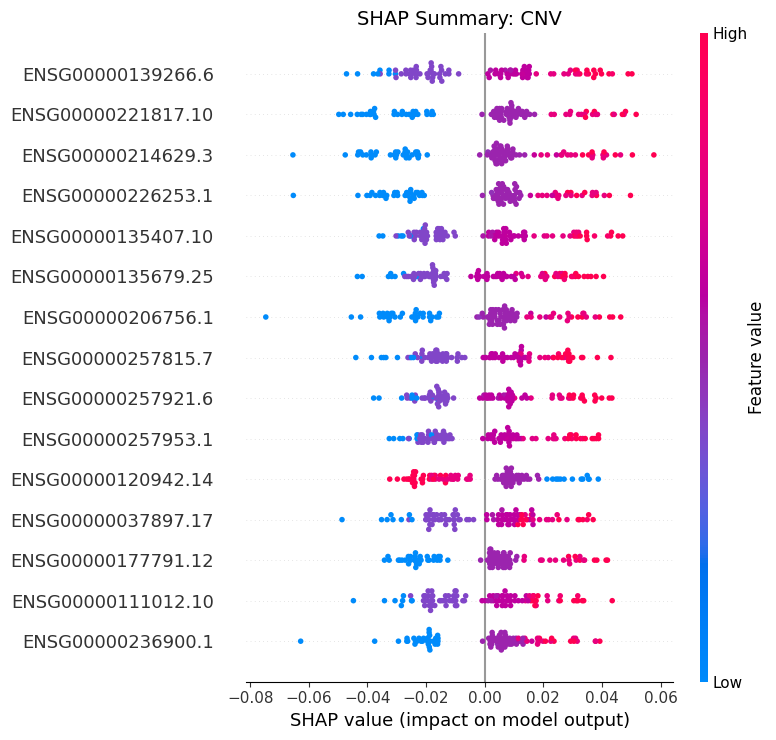


[CNV TOP 15]
   1. ENSG00000257815.7         (SHAP: 0.0090)
   2. ENSG00000135679.25        (SHAP: 0.0089)
   3. ENSG00000236900.1         (SHAP: 0.0088)
   4. ENSG00000221817.10        (SHAP: 0.0088)
   5. ENSG00000150594.7         (SHAP: 0.0087)
   6. ENSG00000206756.1         (SHAP: 0.0086)
   7. ENSG00000214629.3         (SHAP: 0.0080)
   8. ENSG00000226253.1         (SHAP: 0.0080)
   9. ENSG00000139266.6         (SHAP: 0.0078)
  10. ENSG00000213731.2         (SHAP: 0.0076)
  11. ENSG00000256664.1         (SHAP: 0.0075)
  12. ENSG00000257953.1         (SHAP: 0.0073)
  13. ENSG00000135439.11        (SHAP: 0.0073)
  14. ENSG00000232342.7         (SHAP: 0.0072)
  15. ENSG00000266185.2         (SHAP: 0.0072)


In [5]:
# ==============================================================================
# SHAP FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
if HAS_SHAP and 'rna_df' in locals():
    print(f"\n{'='*60}")
    print("SHAP FEATURE IMPORTANCE ANALYSIS (Top 15 Genes per Omic)")
    print(f"{'='*60}")
    print("Training a final model on full data for SHAP analysis...")

    # --- Prepare Full Data (No CV, just for SHAP) ---
    def prepare_full_data_for_shap(df_rna, df_meth, df_cnv, Y):
        """Prepare full dataset for SHAP, returning feature names."""
        print(">>> Training a final model on full data for SHAP analysis (With Name Tracking)...")
        
        # 1. Initial Data & Names (Convert to Numpy for robust indexing)
        X_r, names_r = df_rna.values, df_rna.columns.to_numpy()
        X_m, names_m = df_meth.values, df_meth.columns.to_numpy()
        X_c, names_c = df_cnv.values, df_cnv.columns.to_numpy()
        
        print(f"   [SHAP Prep] Initial Shapes: RNA {X_r.shape}, Meth {X_m.shape}, CNV {X_c.shape}")

        # 2. Variance Filter
        def apply_var_filter(X, names, top_k):
            if X.shape[1] <= top_k: return X, names
            vars = np.nanvar(X, axis=0)
            vars = np.nan_to_num(vars, nan=-1.0)
            top_idx = np.argsort(vars)[-top_k:]
            top_idx = np.sort(top_idx) # preserve order
            return X[:, top_idx], names[top_idx]

        print(f"   [SHAP Prep] Variance Filter...")
        X_r, names_r = apply_var_filter(X_r, names_r, 5000)
        X_m, names_m = apply_var_filter(X_m, names_m, 10000)
        X_c, names_c = apply_var_filter(X_c, names_c, 8000)
        
        # 3. Impute
        print(f"   [SHAP Prep] Imputing...")
        imp = KNNImputer(n_neighbors=12, keep_empty_features=True)
        X_r = imp.fit_transform(X_r)
        X_m = imp.fit_transform(X_m)
        X_c = imp.fit_transform(X_c)

        # 4. mRMR Filter
        def apply_mrmr(X, names, y, top_k, tag):
             if X.shape[1] <= top_k: return X, names
             
             # Reuse existing GPU/CPU logic to get INDICES (0..CurrentFeatures)
             selected_indices = None
             if HAS_CUPY:
                 try:
                     selected_indices = mrmr_gpu_impl(X, y, top_k)
                     if hasattr(selected_indices, 'get'): selected_indices = selected_indices.get()
                     selected_indices = list(selected_indices)
                 except: pass
             
             if selected_indices is None and HAS_MRMR:
                 try:
                    df_temp = pd.DataFrame(X, columns=[f"f_{i}" for i in range(X.shape[1])])
                    selected_feats = mrmr_classif(X=df_temp, y=pd.Series(y), K=top_k, show_progress=False)
                    selected_indices = [int(f.split('_')[1]) for f in selected_feats]
                 except: pass
                 
             if selected_indices is None:
                 vars = np.nanvar(X, axis=0)
                 selected_indices = np.argsort(vars)[-top_k:]
            
             selected_indices = list(selected_indices)
             # Force Limit
             if len(selected_indices) > top_k: selected_indices = selected_indices[:top_k]
             
             # Convert to numpy index array
             idx_arr = np.array(selected_indices, dtype=int)
             
             return X[:, idx_arr], names[idx_arr]

        print(f"   [SHAP Prep] mRMR...")
        X_r, names_r = apply_mrmr(X_r, names_r, Y, 500, "RNA")
        X_m, names_m = apply_mrmr(X_m, names_m, Y, 400, "Meth")
        X_c, names_c = apply_mrmr(X_c, names_c, Y, 300, "CNV")
        
        print(f"   [SHAP Prep] Final Shapes: RNA {X_r.shape}, Meth {X_m.shape}, CNV {X_c.shape}")

        # Scale
        sc = StandardScaler()
        X_r = sc.fit_transform(X_r)
        X_m = sc.fit_transform(X_m)
        X_c = sc.fit_transform(X_c)

        return (
            torch.FloatTensor(X_r).to(DEVICE),
            torch.FloatTensor(X_m).to(DEVICE),
            torch.FloatTensor(X_c).to(DEVICE),
            torch.LongTensor(Y).to(DEVICE),
            names_r.tolist(), names_m.tolist(), names_c.tolist()
        )


    X_r_full, X_m_full, X_c_full, Y_full, rna_names, meth_names, cnv_names = \
        prepare_full_data_for_shap(rna_df, meth_df, cnv_df, Y)

    # --- Train Final Model ---
    enc_r_shap = PerOmicCMAE(X_r_full.shape[1], BEST_PARAMS['latent_dim'], BEST_PARAMS['hidden_dim'], BEST_PARAMS['dropout_encoder']).to(DEVICE)
    enc_m_shap = PerOmicCMAE(X_m_full.shape[1], BEST_PARAMS['latent_dim'], BEST_PARAMS['hidden_dim'], BEST_PARAMS['dropout_encoder']).to(DEVICE)
    enc_c_shap = PerOmicCMAE(X_c_full.shape[1], BEST_PARAMS['latent_dim'], BEST_PARAMS['hidden_dim'], BEST_PARAMS['dropout_encoder']).to(DEVICE)
    fusion_shap = GatedAttentionFusion(BEST_PARAMS['latent_dim'], len(class_names), BEST_PARAMS['dropout_rate'], BEST_PARAMS['fusion_hidden_dim']).to(DEVICE)

    optimizer_shap = optim.AdamW(
        list(enc_r_shap.parameters()) + list(enc_m_shap.parameters()) +
        list(enc_c_shap.parameters()) + list(fusion_shap.parameters()),
        lr=BEST_PARAMS['lr_fine'], weight_decay=BEST_PARAMS['weight_decay']
    )
    alpha_shap = torch.FloatTensor(class_weights * BEST_PARAMS['alpha_scale']).to(DEVICE)
    criterion_shap = FocalLoss(gamma=BEST_PARAMS['focal_gamma'], alpha=alpha_shap)

    print("   Training for SHAP (100 epochs)...")
    for epoch in range(100):
        enc_r_shap.train(); enc_m_shap.train(); enc_c_shap.train(); fusion_shap.train()
        z_r = enc_r_shap(X_r_full, noise_level=BEST_PARAMS['noise_level'])
        z_m = enc_m_shap(X_m_full, noise_level=BEST_PARAMS['noise_level'])
        z_c = enc_c_shap(X_c_full, noise_level=BEST_PARAMS['noise_level'])
        logits, _ = fusion_shap(z_r, z_m, z_c, apply_dropout=False)
        loss = criterion_shap(logits, Y_full)
        optimizer_shap.zero_grad()
        loss.backward()
        optimizer_shap.step()
    print("   Training complete.")

    # --- SHAP Analysis per Encoder ---
    enc_r_shap.eval(); enc_m_shap.eval(); enc_c_shap.eval(); fusion_shap.eval()


    def get_shap_data_for_plot(encoder, fusion_model, X_data, X_r_bg, X_m_bg, X_c_bg, omic_type):
        class EncoderWrapper(nn.Module):
            def __init__(self, enc, fus, omic, bg_r, bg_m, bg_c):
                super().__init__()
                self.enc = enc
                self.fus = fus
                self.omic = omic
                self.bg_r = bg_r.mean(0, keepdim=True)
                self.bg_m = bg_m.mean(0, keepdim=True)
                self.bg_c = bg_c.mean(0, keepdim=True)
            def forward(self, x):
                batch_size = x.shape[0]
                if self.omic == 'RNA':
                    z_r = self.enc(x)
                    z_m = enc_m_shap(self.bg_m.expand(batch_size, -1))
                    z_c = enc_c_shap(self.bg_c.expand(batch_size, -1))
                elif self.omic == 'Meth':
                    z_r = enc_r_shap(self.bg_r.expand(batch_size, -1))
                    z_m = self.enc(x)
                    z_c = enc_c_shap(self.bg_c.expand(batch_size, -1))
                else:
                    z_r = enc_r_shap(self.bg_r.expand(batch_size, -1))
                    z_m = enc_m_shap(self.bg_m.expand(batch_size, -1))
                    z_c = self.enc(x)
                logits, _ = self.fus(z_r, z_m, z_c)
                return logits

        wrapper = EncoderWrapper(encoder, fusion_model, omic_type, X_r_bg, X_m_bg, X_c_bg)
        bg   = X_data[:min(50, len(X_data))]
        test = X_data[:min(100, len(X_data))]
        X_np = test.cpu().numpy()   # (samples, features)
        n_samples, n_features = X_np.shape

        explainer = shap.GradientExplainer(wrapper, bg)
        shap_raw  = explainer.shap_values(test)

        # ---------------------------------------------------------------
        # Determine the actual layout returned by this SHAP version.
        # We observed: sv_plot=(500,4), X_np=(100,500)  →  shap_raw is
        # a list of 100 arrays each (500, 4)  i.e. (features, classes),
        # which means the full tensor is (samples, features, classes).
        #
        # Possible layouts:
        #   A) list[num_classes] of (samples, features)   — classic SHAP
        #   B) ndarray (num_classes, samples, features)   — newer SHAP
        #   C) list[samples]    of (features, classes)    — this version!
        #   D) ndarray (samples, features, classes)       — same as C
        # ---------------------------------------------------------------
        if isinstance(shap_raw, list):
            arr = np.array(shap_raw)   # stack list → ndarray
        else:
            arr = np.array(shap_raw)

        print(f"      [SHAP raw] shape={arr.shape}, X_np={X_np.shape}")

        if arr.ndim == 2:
            # (samples, features) — binary or single output
            sv_3d = arr[:, :, np.newaxis]          # → (samples, features, 1)
        elif arr.ndim == 3:
            s0, s1, s2 = arr.shape
            if s0 == n_samples and s1 == n_features:
                # Layout D: (samples, features, classes)
                sv_3d = arr
            elif s0 == n_samples and s2 == n_features:
                # Layout A stacked: (num_classes, samples, features) but s0==n_samples?
                # Treat as (samples, classes, features) → transpose
                sv_3d = arr.transpose(0, 2, 1)     # → (samples, features, classes)
            elif s2 == n_samples and s0 == n_features:
                # (features, classes, samples) — transpose
                sv_3d = arr.transpose(2, 0, 1)     # → (samples, features, classes)
            elif s0 != n_samples:
                # Layout B: (num_classes, samples, features)
                sv_3d = arr.transpose(1, 2, 0)     # → (samples, features, classes)
            else:
                sv_3d = arr                         # best guess
        else:
            sv_3d = arr.reshape(n_samples, n_features, -1)

        # sv_3d is now (samples, features, classes)
        sv_plot   = sv_3d[:, :, 0]                 # (samples, features) — class 0 for dot plot
        mean_shap = np.mean(np.abs(sv_3d), axis=(0, 2))  # (features,) — avg over samples & classes

        print(f"      [SHAP] sv_plot {sv_plot.shape}, X_np {X_np.shape}, mean_shap {mean_shap.shape}")
        return sv_plot, X_np, mean_shap

    def process_and_plot_shap(omic_name, encoder, X_full, feat_names):
        print(f"   Generating SHAP summary for {omic_name}...")
        n_features = X_full.shape[1]

        # Safety: Ensure names match data dimensions
        if len(feat_names) != n_features:
            print(f"   [SHAP PLOT] Warning: Name mismatch for {omic_name}! X: {n_features}, Names: {len(feat_names)}")
            feat_names = list(feat_names)
            if len(feat_names) < n_features:
                feat_names += [f"Feat_{i}" for i in range(len(feat_names), n_features)]
            else:
                feat_names = feat_names[:n_features]

        # get_shap_data_for_plot now returns 3 values
        sv_plot, X_test_np, mean_shap = get_shap_data_for_plot(
            encoder, fusion_shap, X_full, X_r_full, X_m_full, X_c_full, omic_name
        )
        # sv_plot   : (samples, features)  — signed, for dot plot
        # X_test_np : (samples, features)  — matching numpy data
        # mean_shap : (features,)          — mean |SHAP| across all classes

        # Gene Name Conversion (Ensembl → Symbol)
        display_names = list(feat_names)
        if HAS_MYGENE and omic_name in ['RNA', 'CNV']:
            if len(feat_names) > 0 and (str(feat_names[0]).startswith('ENSG') or 'ENSG' in str(feat_names[0])):
                print(f"      Mapping {omic_name} Ensembl IDs to gene symbols...")
                mg = mygene.MyGeneInfo()
                try:
                    res = mg.querymany(feat_names, scopes='ensembl.gene', fields='symbol', species='human', verbose=False)
                    mapping = {item['query']: item.get('symbol', item['query']) for item in res}
                    display_names = [mapping.get(n, n) for n in feat_names]
                except Exception as e:
                    print(f"      MyGene mapping failed: {e}")

        # Summary Plot — sv_plot (samples, features) matches X_test_np exactly
        try:
            plt.figure(figsize=(10, 6))
            plt.title(f"SHAP Summary: {omic_name}", fontsize=14)
            shap.summary_plot(sv_plot, X_test_np, feature_names=display_names,
                              max_display=15, show=False, plot_type='dot')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"      [SHAP Plot] summary_plot failed ({e}), falling back to bar plot.")
            plt.figure(figsize=(10, 6))
            plt.title(f"SHAP Feature Importance: {omic_name}", fontsize=14)
            shap.summary_plot(sv_plot, X_test_np, feature_names=display_names,
                              max_display=15, show=False, plot_type='bar')
            plt.tight_layout()
            plt.show()

        # Ensure mean_shap is exactly (n_features,)
        mean_shap = mean_shap.flatten()
        if len(mean_shap) != n_features:
            print(f"      [{omic_name}] WARNING: mean_shap length {len(mean_shap)} != n_features {n_features}.")
            mean_shap = mean_shap[:n_features] if len(mean_shap) > n_features else \
                        np.pad(mean_shap, (0, n_features - len(mean_shap)))

        top_ids = np.argsort(mean_shap)[-15:][::-1]

        print(f"\n[{omic_name} TOP 15]")
        for i, idx in enumerate(top_ids, 1):
            idx = int(idx)
            vn = display_names[idx] if idx < len(display_names) else f"OOB_{idx}"
            print(f"  {i:2d}. {str(vn):25s} (SHAP: {mean_shap[idx]:.4f})")

    process_and_plot_shap('RNA', enc_r_shap, X_r_full, rna_names)
    process_and_plot_shap('Meth', enc_m_shap, X_m_full, meth_names)
    process_and_plot_shap('CNV', enc_c_shap, X_c_full, cnv_names)


else:
    if not HAS_SHAP:
        print("\nSHAP analysis skipped: shap library not installed.")
    else:
        print("\nSHAP analysis skipped: Required data not available.")